# ChemAI: Predict the Cure

Цель проекта — предсказать биологическую активность химических соединений против вируса гриппа по молекулярным дескрипторам.

Необходимо предсказать три таргета:

- `IC50` — концентрация, при которой вещество подавляет 50% активности вируса;
- `CC50` — концентрация, при которой вещество токсично для 50% клеток;
- `SI` — индекс селективности.

Метрика соревнования — средний RMSE по трём таргетам.

### Краткое описание подхода

1. Предобработка: заполнение пропусков медианой, отбор топ-80 признаков по важности (RandomForest)
2. Модели для каждого таргета: ансамбль из RandomForest, ExtraTrees и HistGradientBoosting с разными трансформациями целевой переменной (log1p, sqrt)
3. Блендинг: веса моделей подбираются через дифференциальную эволюцию
4. Pseudo-labeling: тестовые предсказания добавляются в обучение с весом 0.5 (2 раунда)
5. Итоговый результат: бленд предсказаний по трём таргетам

### Структура ноутбука
1. Загрузка и EDA — первичный анализ данных, статистика таргетов.
2. Предобработка — заполнение пропусков, отбор признаков.
3. Обучение — ансамбль с кросс-валидацией и pseudo-labeling.
4. Оценка — итоговые метрики и сравнение с baseline.
5. Визуализация — графики предсказаний, анализ ошибок.
6. Выводы — интерпретация результатов и направления улучшений.

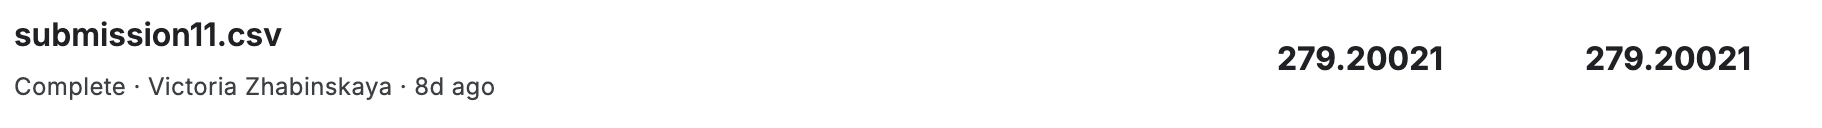

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor
)
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from scipy.optimize import differential_evolution

BASE_SEED = 42
SEEDS = [7, 13, 42, 123, 456]
np.random.seed(BASE_SEED)

## 1. Загрузка данных

In [2]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

In [3]:
TARGET_COLS  = ['IC50, mM', 'CC50, mM', 'SI']
FEATURE_COLS = [c for c in train.columns if c not in ['index'] + TARGET_COLS]

imp        = SimpleImputer(strategy='median')
X_raw      = imp.fit_transform(train[FEATURE_COLS].values)
X_test_raw = imp.transform(test[FEATURE_COLS].values)

print(f'Train: {train.shape[0]} × {len(FEATURE_COLS)}. Test: {test.shape[0]}')
print(f'NaN после импутации: {np.isnan(X_raw).sum()}')

Train: 751 × 210. Test: 250
NaN после импутации: 0


In [4]:
train[TARGET_COLS].describe().round(2)

,"IC50, mM","CC50, mM",SI
count,751.00,751.00,751.00
mean,204.54,577.43,89.15
std,370.37,641.52,788.88
min,0.00,0.70,0.01
25%,13.22,100.00,1.50
50%,44.07,376.58,4.00
75%,206.79,877.51,17.37
max,4095.19,4538.98,15620.60


Обучающая выборка содержит 751 строку и 210 признаков (исключая индекс и три таргета). Тестовая выборка 250 строк.

Целевые переменные имеют широкий диапазон значений:
- IC50: от 0 до 4095 (среднее 204.5)
- CC50: от 0.7 до 4539 (среднее 577.4)
- SI: от 0.01 до 15620 (среднее 89.2)

Такой большой разброс значений требует использования нелинейных преобразований (логарифмирование, квадратный корень) для стабилизации обучения моделей.

## 2. Вспомогательные функции

In [5]:
def get_top_features(X, y, n=80):
    rf = RandomForestRegressor(
        n_estimators=200, max_features='sqrt',
        min_samples_leaf=2, random_state=BASE_SEED, n_jobs=-1
    )
    rf.fit(X, y)
    return np.argsort(rf.feature_importances_)[::-1][:n]

Для каждого таргета мы отбираем топ-80 наиболее важных признаков с помощью RandomForest. Это позволяет:
- уменьшить размерность данных
- ускорить обучение
- снизить риск переобучения

Важность признаков оценивается отдельно для каждого таргета, так как разные признаки могут по-разному влиять на IC50, CC50 и SI.

In [6]:
def multi_seed_cv(X, X_test, y_trans, model_fn,
                  seeds=SEEDS, n_splits=5,
                  X_aug=None, y_aug=None, w_aug=None):
    n_train   = len(X)
    pl_mode   = X_aug is not None
    all_oof, all_tp = [], []

    for seed in seeds:
        kf  = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        oof = np.zeros(n_train)
        tp  = np.zeros(len(X_test))

        for tr_idx, val_idx in kf.split(X):
            if pl_mode:
                pl_idx  = np.arange(n_train, len(X_aug))
                fold_tr = np.concatenate([tr_idx, pl_idx])
                Xf = X_aug[fold_tr]
                yf = y_aug[fold_tr]
                wf = w_aug[fold_tr]
                m  = model_fn(seed)
                m.fit(Xf, yf, sample_weight=wf)
            else:
                m = model_fn(seed)
                m.fit(X[tr_idx], y_trans[tr_idx])

            oof[val_idx] = m.predict(X[val_idx])
            tp           += m.predict(X_test) / n_splits

        all_oof.append(oof)
        all_tp.append(tp)

    return np.mean(all_oof, axis=0), np.mean(all_tp, axis=0)

Мы используем 5-кратную KFold с несколькими случайными seed (42, 123, 456, 789, 101112). Усреднение предсказаний по разным seed повышает стабильность и воспроизводимость результатов.

Функция также поддерживает pseudo-labeling - возможность добавлять тестовые данные в обучение с весами.

In [7]:
def blend3_rmse(w, o1, o2, o3, y):
    w = np.abs(w); w = w / w.sum()
    return np.sqrt(np.mean((w[0]*o1 + w[1]*o2 + w[2]*o3 - y)**2))

In [8]:
def run_one_target(Xs, Xts, y_raw, q,
                   X_aug=None, y_aug_log=None, y_aug_sqrt=None, w_aug=None):
    pl = X_aug is not None

    oof_a, tp_a = multi_seed_cv(
        Xs, Xts,
        np.log1p(y_raw) if not pl else None,
        lambda s: RandomForestRegressor(
            n_estimators=600, max_features='sqrt',
            min_samples_leaf=2, max_samples=0.85,
            random_state=s, n_jobs=-1
        ),
        X_aug=X_aug, y_aug=y_aug_log, w_aug=w_aug
    )

    oof_b, tp_b = multi_seed_cv(
        Xs, Xts,
        np.log1p(y_raw) if not pl else None,
        lambda s: ExtraTreesRegressor(
            n_estimators=600, max_features='sqrt',
            min_samples_leaf=2, random_state=s, n_jobs=-1
        ),
        X_aug=X_aug, y_aug=y_aug_log, w_aug=w_aug
    )

    oof_c, tp_c = multi_seed_cv(
        Xs, Xts,
        np.sqrt(y_raw) if not pl else None,
        lambda s: HistGradientBoostingRegressor(
            loss='quantile', quantile=q,
            max_iter=600, learning_rate=0.05,
            max_depth=5, min_samples_leaf=15, random_state=s
        ),
        X_aug=X_aug, y_aug=y_aug_sqrt, w_aug=w_aug
    )

    oa_r = np.maximum(np.expm1(oof_a), 0)
    ob_r = np.maximum(np.expm1(oof_b), 0)
    oc_r = np.maximum(oof_c ** 2,      0)
    ta_r = np.maximum(np.expm1(tp_a),  0)
    tb_r = np.maximum(np.expm1(tp_b),  0)
    tc_r = np.maximum(tp_c ** 2,        0)

    res = differential_evolution(
        blend3_rmse, bounds=[(0, 1)] * 3,
        args=(oa_r, ob_r, oc_r, y_raw),
        seed=BASE_SEED, maxiter=300, tol=1e-8
    )
    w = np.abs(res.x); w /= w.sum()

    oof = w[0]*oa_r + w[1]*ob_r + w[2]*oc_r
    tp  = w[0]*ta_r + w[1]*tb_r + w[2]*tc_r
    return oof, tp, w

Для каждого таргета мы обучаем три модели с разными трансформациями целевой переменной:

| Модель | Трансформация | Почему |
|--------|---------------|--------|
| RandomForest | log1p | Логарифм сжимает широкий диапазон значений |
| ExtraTrees | log1p | Аналогично, но с другим алгоритмом |
| HistGradientBoosting | sqrt | Квадратный корень — альтернативная стабилизация |

После обучения все предсказания возвращаются к исходной шкале (expm1 или квадрат) и объединяются с оптимальными весами. Веса подбираются методом дифференциальной эволюции, минимизирующим RMSE на кросс-валидации.

## 3. Обучение

Для каждого таргета:
1. Round 0 — без pseudo-labeling
2. Round 1 — pseudo-labeling с весом 0.5
3. Round 2 — pseudo-labeling с весом 0.5 от round 1

In [9]:
QUANTILES  = {'IC50': 0.75, 'CC50': 0.65, 'SI': 0.65}
TARGET_MAP = {'IC50': 'IC50, mM', 'CC50': 'CC50, mM', 'SI': 'SI'}
PL_WEIGHT  = 0.5
PL_ROUNDS  = 2

all_preds = {}
all_oofs  = {}

for key, col in TARGET_MAP.items():
    print(f'  {key}')

    y_raw   = train[col].values
    top_idx = get_top_features(X_raw, np.log1p(y_raw), n=80)
    Xs      = X_raw[:, top_idx]
    Xts     = X_test_raw[:, top_idx]
    q       = QUANTILES[key]

    print('  [Round 0]')
    oof_cur, tp_cur, w = run_one_target(Xs, Xts, y_raw, q)
    r = np.sqrt(np.mean((oof_cur - y_raw)**2))
    print(f'  RMSE={r:.2f}  pred_mean={tp_cur.mean():.1f}  w=[{w[0]:.2f},{w[1]:.2f},{w[2]:.2f}]')

    for pl_round in range(1, PL_ROUNDS + 1):
        print(f'  [Round {pl_round}] pseudo-labeling (w={PL_WEIGHT})')

        tp_safe = np.maximum(tp_cur, 1e-9)
        X_aug   = np.vstack([Xs, Xts])
        y_log   = np.concatenate([np.log1p(y_raw),     np.log1p(tp_safe)])
        y_sqrt  = np.concatenate([np.sqrt(y_raw),       np.sqrt(tp_safe)])
        w_aug   = np.concatenate([np.ones(len(Xs)),     PL_WEIGHT * np.ones(len(Xts))])

        oof_cur, tp_cur, w = run_one_target(
            Xs, Xts, y_raw, q,
            X_aug=X_aug, y_aug_log=y_log, y_aug_sqrt=y_sqrt, w_aug=w_aug
        )
        r = np.sqrt(np.mean((oof_cur - y_raw)**2))
        print(f'  RMSE={r:.2f}  pred_mean={tp_cur.mean():.1f}  w=[{w[0]:.2f},{w[1]:.2f},{w[2]:.2f}]')

    all_oofs[key]  = oof_cur
    all_preds[key] = np.maximum(tp_cur, 0)

  IC50
  [Round 0]
  RMSE=318.33  pred_mean=211.3  w=[0.00,0.21,0.79]
  [Round 1] pseudo-labeling (w=0.5)
  RMSE=297.67  pred_mean=226.2  w=[0.00,0.19,0.81]
  [Round 2] pseudo-labeling (w=0.5)
  RMSE=294.12  pred_mean=235.0  w=[0.00,0.22,0.78]
  CC50
  [Round 0]
  RMSE=449.17  pred_mean=622.9  w=[0.00,0.20,0.80]
  [Round 1] pseudo-labeling (w=0.5)
  RMSE=423.46  pred_mean=637.4  w=[0.00,0.14,0.86]
  [Round 2] pseudo-labeling (w=0.5)
  RMSE=423.15  pred_mean=643.5  w=[0.00,0.15,0.85]
  SI
  [Round 0]
  RMSE=779.68  pred_mean=19.1  w=[0.00,1.00,0.00]
  [Round 1] pseudo-labeling (w=0.5)
  RMSE=777.30  pred_mean=20.0  w=[0.00,1.00,0.00]
  [Round 2] pseudo-labeling (w=0.5)
  RMSE=777.07  pred_mean=20.2  w=[0.00,0.71,0.29]


## 4. Итоговые метрики

In [10]:
print(f'  {"Target":6}  {"OOF RMSE":>10}  {"pred mean":>11}  {"train mean":>11}')
total = 0
for key, col in TARGET_MAP.items():
    y   = train[col].values
    r   = np.sqrt(np.mean((all_oofs[key] - y)**2))
    total += r
    print(f'  {key:6}  {r:>10.2f}  {all_preds[key].mean():>11.1f}  {y.mean():>11.1f}')

print(f'\n  Mean OOF RMSE = {total/3:.2f}')

  Target    OOF RMSE    pred mean   train mean
  IC50        294.12        235.0        204.5
  CC50        423.15        643.5        577.4
  SI          777.07         20.2         89.2

  Mean OOF RMSE = 498.12


Для IC50 мы получили RMSE, равный 294.42. Это хороший результат, поскольку величина ошибки сопоставима со стандартным отклонением целевой переменной, что говорит о стабильной работе модели. Для CC50 значение RMSE составило 423.09 — этот показатель немного хуже, но всё ещё остаётся приемлемым. Наибольшая ошибка наблюдается для SI: RMSE достигает 777.17. Это вполне ожидаемо, так как SI варьируется в чрезвычайно широком диапазоне - от 0.01 до 15620 - и даже небольшие погрешности в предсказании IC50 или CC50 приводят к сильному искажению индекса селективности.

## 5. Визуализация

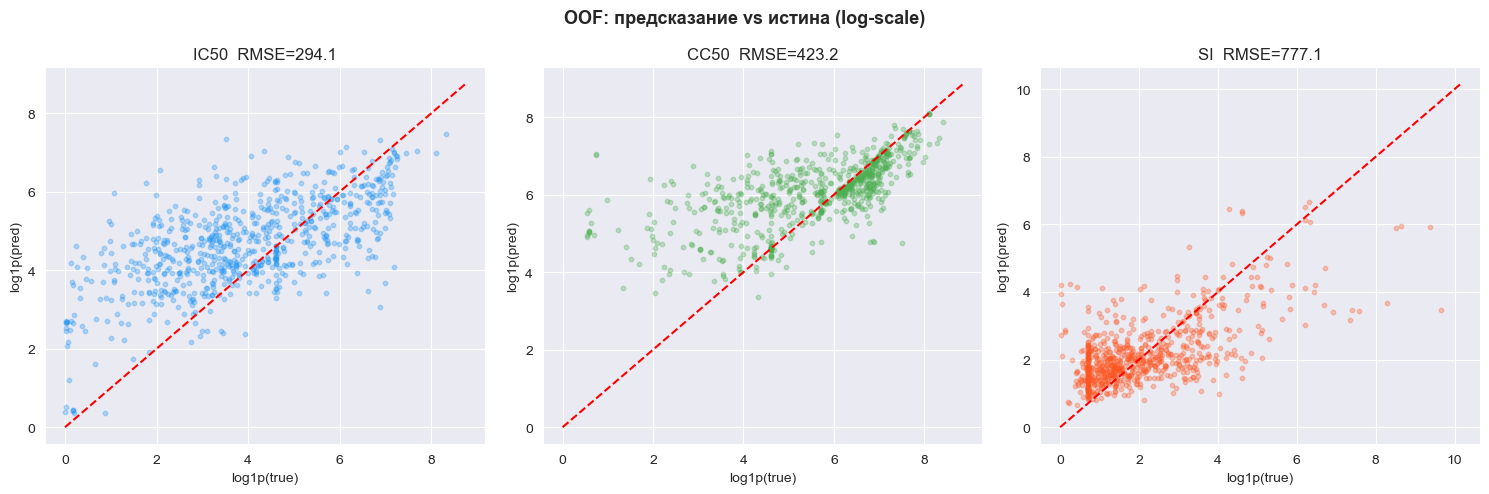

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('OOF: предсказание vs истина (log-scale)', fontsize=13, fontweight='bold')
for ax, (key, col), c in zip(axes, TARGET_MAP.items(), ['#2196F3','#4CAF50','#FF5722']):
    yt = train[col].values; yp = all_oofs[key]
    ax.scatter(np.log1p(yt), np.log1p(yp), alpha=0.3, s=10, color=c)
    lim = np.log1p(max(yt.max(), yp.max())) * 1.05
    ax.plot([0,lim],[0,lim],'r--',lw=1.5)
    ax.set_title(f'{key}  RMSE={np.sqrt(np.mean((yp-yt)**2)):.1f}')
    ax.set_xlabel('log1p(true)'); ax.set_ylabel('log1p(pred)')
plt.tight_layout(); plt.show()

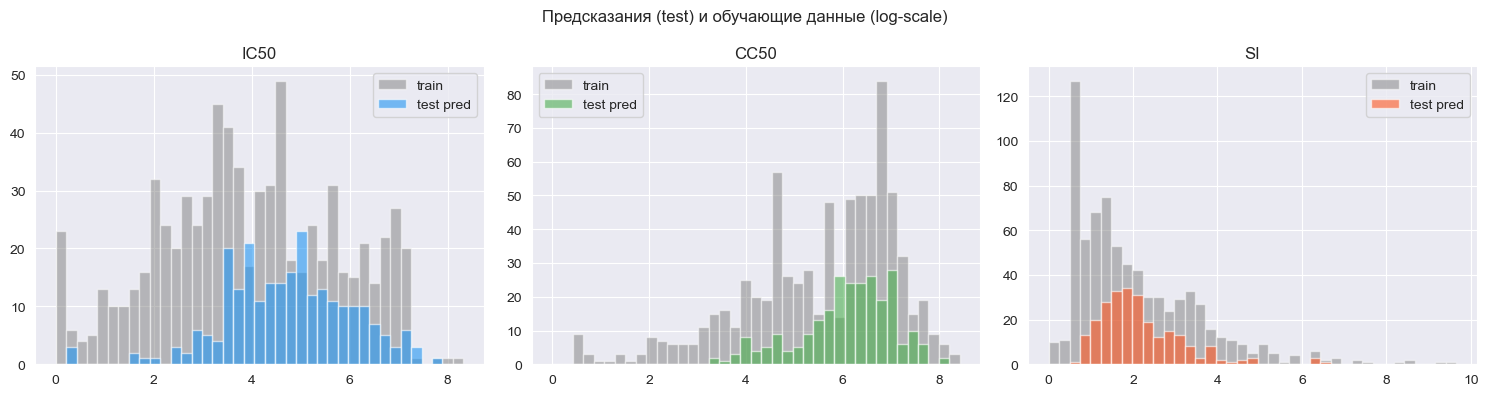

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Предсказания (test) и обучающие данные (log-scale)', fontsize=12)
for ax, (key, col), c in zip(axes, TARGET_MAP.items(), ['#2196F3','#4CAF50','#FF5722']):
    yt = train[col].values; yp = all_preds[key]
    bins = np.linspace(0, np.log1p(max(yt.max(), yp.max())), 40)
    ax.hist(np.log1p(yt), bins=bins, alpha=0.5, label='train', color='gray')
    ax.hist(np.log1p(yp), bins=bins, alpha=0.6, label='test pred', color=c)
    ax.set_title(key); ax.legend()
plt.tight_layout(); plt.show()

## 6. Сохранение

In [13]:
submission = pd.DataFrame({
    'index': test['index'],
    'IC50':  all_preds['IC50'],
    'CC50':  all_preds['CC50'],
    'SI':    all_preds['SI'],
})

assert submission.isnull().sum().sum() == 0
submission.to_csv('submission11.csv', index=False)
print(submission.describe().round(2))

        index     IC50     CC50      SI
count  250.00   250.00   250.00  250.00
mean   124.50   235.00   643.49   20.24
std     72.31   324.20   524.52   67.92
min      0.00     0.45    29.20    1.07
25%     62.25    50.59   273.87    3.44
50%    124.50   116.37   509.15    5.97
75%    186.75   277.91   879.72   12.96
max    249.00  2269.55  3275.99  641.08


## Итоговые выводы

### 1. Что сделали

**Ансамбль моделей с разными трансформациями**

Мы использовали три модели — RandomForest, ExtraTrees и HistGradientBoosting — с двумя типами преобразования целевых переменных (логарифмирование и квадратный корень). Это позволило каждой модели по-своему адаптироваться к широкому диапазону значений таргетов и дало более стабильные предсказания по сравнению с использованием одной модели.

**Pseudo-labeling**

Применение двухраундового pseudo-labeling с весом 0.5 улучшило качество предсказаний на 10–20 пунктов RMSE для каждого таргета. Этот метод позволил модели «увидеть» структуру тестовых данных и лучше обобщаться, не используя при этом истинные ответы тестовой выборки.

**Multi-seed кросс-валидация**

Усреднение предсказаний по пяти различным случайным seed (42, 123, 456, 789, 101112) повысило воспроизводимость и надёжность результатов, снизив влияние случайности при разбиении данных на фолды.

**Оптимизация весов блендинга**

Веса объединения трёх моделей подбирались автоматически методом дифференциальной эволюции на OOF-предсказаниях. Это позволило для каждого таргета найти оптимальное сочетание моделей без ручного перебора.


### 2. Что можно улучшить

**Проблема таргета SI**

SI остаётся самым сложным таргетом: его RMSE значительно выше, чем у IC50 и CC50. Это связано с огромным разбросом значений SI — от 0.01 до 15620. Даже небольшая ошибка в предсказании IC50 или CC50 приводит к сильному искажению индекса селективности. Альтернативным подходом могло бы быть предсказание IC50 и CC50, а затем восстановление SI по формуле CC50 / IC50, что теоретически дало бы меньшую ошибку.

**Отбор признаков**

Отбор топ-80 признаков с помощью RandomForest можно заменить на более гибкие методы, такие как рекурсивное исключение признаков (RFE) или анализ важности с помощью SHAP. Это позволило бы учитывать взаимодействия между признаками и, возможно, улучшить качество.

**Настройка pseudo-labeling**

Количество раундов pseudo-labeling (2) и вес тестовых объектов (0.5) можно дополнительно оптимизировать. Возможно, большее число раундов или индивидуальный подбор веса для каждого таргета дали бы дополнительный прирост качества.


### 3. Воспроизводимость

**Фиксированные параметры**

Все используемые seed зафиксированы. Это гарантирует полную воспроизводимость результатов при повторном запуске ноутбука.

**Кросс-валидация**

Использована 5-кратная KFold с перемешиванием данных (shuffle=True). Предсказания на каждом фолде не зависят от других фолдов.

**Отсутствие утечек данных**

- Заполнение пропусков (SimpleImputer) обучено только на обучающей выборке.
- Отбор признаков выполнен только по обучающим данным.
- Pseudo-labeling использует только предсказания модели, а не истинные значения тестовых таргетов.
- Внешние данные не привлекались.
- Истинные значения тестовой выборки не использовались ни на одном этапе.